# Churn Analysis (EDA)


### 1. Dataset

First things first, we need to understand our dataset. This notebook will detail the exploratory analysis as well as the dataset, this is important as EDA summarizes the data behaviour and their caracteristics. It is very useful to analyse how the target variable (churn) behaves when compared with the other ones, especially to anwers such as: Does have a partner changes the churn rate? What about the gender? Lets have a look in our data.\
There are 21 columns about customer data, here is the detail of each column:

**- customerID:** Unique ID for every customer;\
**- Gender:** Male or Female;\
**- SeniorCitizen:** Whether the customer is a senior citizen or not;\
**- Partner:** Whether the customer has a partner or not;\
**- Dependents:** Whether the customer has dependents or not;\
**- Tenure:** Number of months the customer stayed with company;\
**- PhoneService:** Whether the customer has a phone service or not;\
**- MultipleLines:** Whether the customer has multiple lines or not;\
**- InternetService:** Type of service provider (DSL, fiber optic, No),\
**- OnlineSecurity:** Whether customer has online security or not;\
**- OnlineBackup:** Whether the customer has online backup or not;\
**- DeviceProtection:** Whether the customer has device protection or not;\
**- TechSupport:** Whether the customer has tech support or not;\
**- StreamingTV:** Whether the customer has streaming TV or not;\
**- StreamingMovies:** Whether the customer has streaming movies or not;\
**- Contract:** The contract term of the customer;\
**- PaperlessBilling:** Whether the customer has paperless billing or not;\
**- PaymentMethod:** The customer’s payment method;\
**- MonthlyCharges:** The amount charged to the customer monthly;\
**- TotalCharges:** The total amount charged to the customer;\
**- Churn:** Whether the customer churned or not.\

Basically, there are demographic information (gender, partners, dependents) and about services purchased by customers. Throughout EDA we can understand what variables (information) are important and have strong relation with whether the customer churned or not. This can be important as we do not need to utilise all of them when training our prediction model in the future, a simple model can be as good as a robust model with many variables and even though provide a good performance (leading us using less memory and resources).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


df = pd.read_csv("/workspaces/churn-analysis/datasets/telco_customers.csv")

# Display the first few rows of the dataframe
df.head(3)

df = df.drop(['customerID'], axis=1)

### 2. Data cleaning and transformation


In [4]:
# Standardizing column names: lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

#transforming totalcharges to numeric, coerce errors to 0
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df.fillna({'totalcharges':0}, inplace=True)

categorical_cols = df.select_dtypes(include=['str']).columns
print(categorical_cols)

# Standardize categorical column values (replace spaces with underscores and convert to lowercase)
for col in categorical_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')



Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod', 'churn'],
      dtype='str')


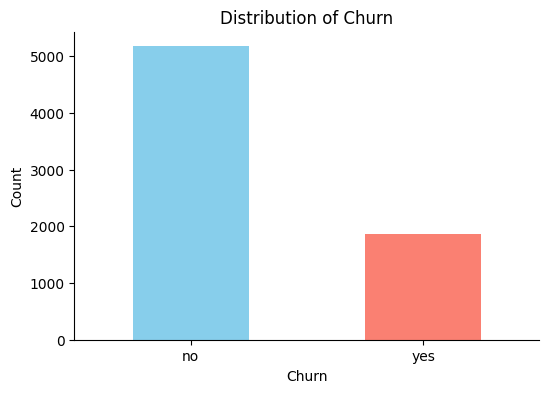

Global Churn Rate: 26.54%


In [5]:
#Plotting the distribution of target variable 'churn'
plt.figure(figsize=(6,4))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
df['churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

global_churn = df['churn'].value_counts(normalize=True)['yes']
print(f"Global Churn Rate: {global_churn:.2%}")

The global churn rate is 26.54%, indicating that roughly a quarter of our customers are expected to churn. While we use contingency tables for categorical data, we evaluate the correlation for numerical variables to identify strong predictors.

In [6]:
for col in categorical_cols:
    print(f"Contigency table for {col}:")
    print(pd.crosstab(df[col], df['churn']))
    print("\n")
    print("Chi-square test results:")
    chi2, p, dof, ex = stats.chi2_contingency(pd.crosstab(df[col], df['churn']))
    print(f"Chi2: {chi2}, p-value: {p}")
    print("-" * 30)

Contigency table for gender:
churn     no  yes
gender           
female  2549  939
male    2625  930


Chi-square test results:
Chi2: 0.4840828822091383, p-value: 0.48657873605618596
------------------------------
Contigency table for partner:
churn      no   yes
partner            
no       2441  1200
yes      2733   669


Chi-square test results:
Chi2: 158.7333820309922, p-value: 2.1399113440759935e-36
------------------------------
Contigency table for dependents:
churn         no   yes
dependents            
no          3390  1543
yes         1784   326


Chi-square test results:
Chi2: 189.12924940423474, p-value: 4.9249216612154196e-43
------------------------------
Contigency table for phoneservice:
churn           no   yes
phoneservice            
no             512   170
yes           4662  1699


Chi-square test results:
Chi2: 0.9150329892546948, p-value: 0.3387825358066928
------------------------------
Contigency table for multiplelines:
churn               no  yes
multiplel

As we can see in the above code, we are performing a chi-square test of independence for each categorical variable against the target variable 'churn'. 
The chi-square test helps us determine if there is a significant association between the categorical variable and churn.
There is a significant association between almost all the categorical variables and churn, except for gender and phoneservice. 
It is a good idea to investigate after how these variables are performing in the model.

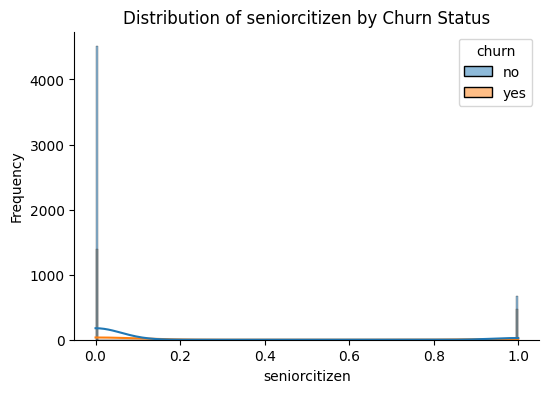

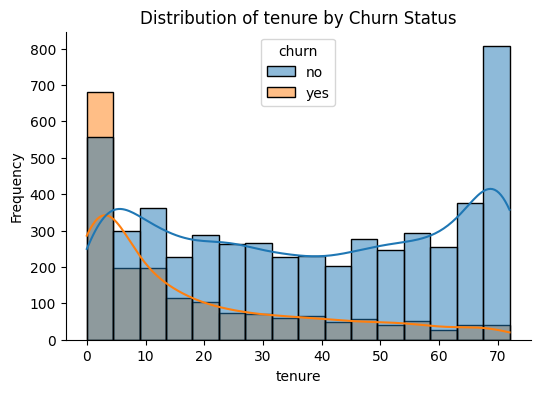

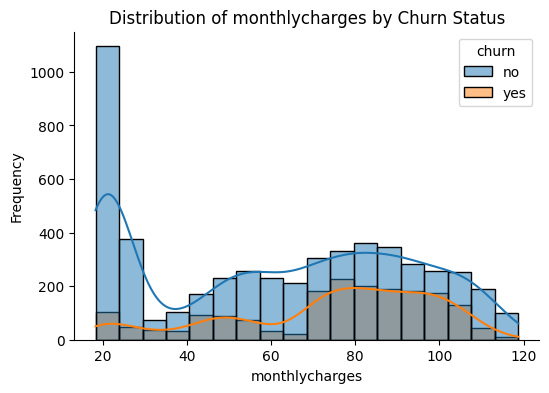

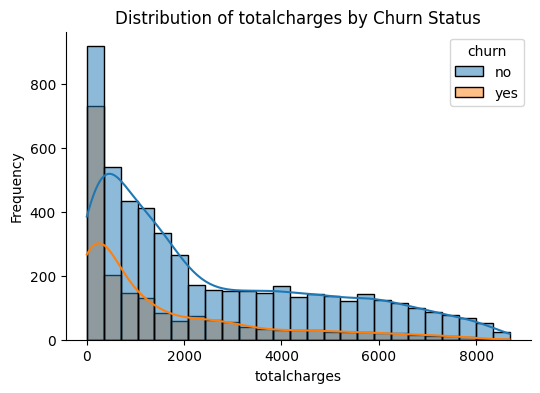

In [7]:
#Histogram of numerical features between churn and non-churn customers
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='churn', kde=True)
    plt.title(f'Distribution of {col} by Churn Status')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

From the graphs above we can see the distribution of totalcharges among the churned group and non-churned group behaves similarly, which indicates that maybe this is a not a good predictor for the model.

In [ ]:
# Correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

corr = df[numerical_cols].corr()
corr.style.background_gradient(cmap='coolwarm')

,seniorcitizen,tenure,monthlycharges,totalcharges
seniorcitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
monthlycharges,0.220173,0.247900,1.000000,0.651174
totalcharges,0.103006,0.826178,0.651174,1.000000


The correlation analysis help us identify two or more variable are strongly correlated, we can consider to use just one of them if they are strongly correlated as it prevents bad predictions.

In [ ]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
len(df_full_train), len(df_test)

df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1) # Further splitting to get 60% train, 20% val, 20% test
len(df_train), len(df_val), len(df_test)

# Exporting the datasets
df_train.to_csv("/workspaces/churn-analysis/datasets/train.csv", index=False)
df_val.to_csv("/workspaces/churn-analysis/datasets/val.csv", index=False)
df_test.to_csv("/workspaces/churn-analysis/datasets/test.csv", index=False)